# Social Media Analytics Project: Academic Year 2025/2026
## Title: Digital Discourse on Climate Security: Structural Resilience and Emotional Paradoxes during COP27

**Authors:** Any Das (922710), Arnab Biswas (925349) & Summan Gul (925663)

**Objective:** This notebook applies Social Network and Content Analysis to examine climate security discourse during COP27. It maps structural patterns and tracks emotional shifts to uncover key paradoxes between network resilience and sentiment volatility.


## Environment Setup and Helper Functions


In [24]:
!pip install python-louvain wordcloud

In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

# Core Python Libraries
import re
import random
import warnings
from datetime import datetime, timedelta
warnings.filterwarnings("ignore")

# Data Handling
import pandas as pd
import numpy as np

# Network Analysis
import networkx as nx
import community.community_louvain as community_louvain

# Visualization
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.cm as cm
import matplotlib.dates as mdates
import seaborn as sns

# Text Visualization
from wordcloud import WordCloud

# Plot Annotations
from matplotlib.offsetbox import AnchoredText

# Pretty Table Function
def pretty(df):
    return df.style.set_properties(**{
        'border': '1px solid black',
        'padding': '4px',
        'text-align': 'left'
    }).set_table_styles([
        {
            'selector': 'th',
            'props': [
                ('border', '1px solid black'),
                ('background-color', '#F2F2F2'),
                ('font-weight', 'bold')
            ]
        }
    ])

# Parse Gephi / Excel Serial Dates
def parse_gephi_date(timeset_str):
    try:
        match = re.search(r'\[(\d+(\.\d+)?)', str(timeset_str))
        if match:
            serial_date = float(match.group(1))
            return datetime(1899, 12, 30) + timedelta(days=serial_date)
    except:
        return None
    return None


Mounted at /content/drive


## 1. Social Network Analysis
This section builds the hashtag network and begins with a descriptive exploration of top nodes and edges. It uses k-core decomposition to find key nodes, Louvain algorithm for community detection, and Centrality measures (Degree vs. Betweenness) to identify top influencers. It also tracks weighted network density over time and evaluates global assortativity to test for echo chambers.

### 1.1 Nodes Data Analysis and Pre-processing

In [ ]:
file_path_nodes = "/content/drive/MyDrive/SMA_Das_Biswas_Gul/Climate_Security_Datasets/CS-co-hashtags-net_dynamic_NODES.csv"
df_nodes = pd.read_csv(file_path_nodes)
print("--- INITIAL CHECK ---")
print(f"Loaded Rows: {len(df_nodes)}")
print(f"Loaded Columns: {len(df_nodes.columns)}")

# REMOVE JUNK COLUMNS
valid_cols = [c for c in df_nodes.columns if not c.startswith('Unnamed')]
df_nodes = df_nodes[valid_cols]
print(f"\n-> Removing junk columns. Keeping: {df_nodes.columns.tolist()}")

--- INITIAL CHECK ---
Loaded Rows: 58019
Loaded Columns: 2283

-> Removing junk columns. Keeping: ['Id', 'Label', 'timeset', 'frequency', 'type']


In [ ]:
print(f"Total Rows: {len(df_nodes)}")
print("\n---Missing Values (Null Check)---")
print(df_nodes.isnull().sum())
print("\n---Data Types (Info)---")
df_nodes.info()


Total Rows: 58019

---Missing Values (Null Check)---
Id            0
Label         0
timeset       0
frequency    40
type         40
dtype: int64

---Data Types (Info)---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58019 entries, 0 to 58018
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Id         58019 non-null  object
 1   Label      58019 non-null  object
 2   timeset    58019 non-null  object
 3   frequency  57979 non-null  object
 4   type       57979 non-null  object
dtypes: object(5)
memory usage: 2.2+ MB


In [ ]:
START_DATE = '2022-06-01'
END_DATE = '2023-05-31'

# Apply Date Parser DIRECTLY to 'timeset'
df_nodes['timeset'] = df_nodes['timeset'].apply(parse_gephi_date)
# Filter for New Timeframe
df_nodes_filtered = df_nodes[
    (df_nodes['timeset'] >= START_DATE) &
    (df_nodes['timeset'] <= END_DATE)
].copy()

# Clean Frequency Column (Ensure Integer)
df_nodes_filtered['frequency'] = pd.to_numeric(df_nodes_filtered['frequency'], errors='coerce')
# Drop rows where frequency is NaN
df_nodes_filtered.dropna(subset=['frequency'], inplace=True)
df_nodes_filtered['frequency'] = df_nodes_filtered['frequency'].astype(int)
# Rename Column (timeset -> timestamp)
df_nodes_filtered.rename(columns={'timeset': 'timestamp'}, inplace=True)
# Handle Missing Values for Text Columns
df_nodes_filtered['type'] = df_nodes_filtered['type'].fillna('Unknown')

output_nodes = '/content/drive/MyDrive/SMA_Das_Biswas_Gul/Climate_Security_Datasets/nodes_June2022toMay2023_FINAL.csv'
df_nodes_filtered.to_csv(output_nodes, index=False)

# CHECK FINAL DATA
print(f"Filtered Rows ({START_DATE} to {END_DATE}): {len(df_nodes_filtered)}")
print("\n--- Missing Values ---")
print(df_nodes_filtered.isnull().sum())
print(f"\n-> Saved to: {output_nodes}")
print("\n--- First 5 Rows ---")
try:
    display(pretty(df_nodes_filtered.head(5)))
except:
    display(df_nodes_filtered.head(5))

Filtered Rows (2022-06-01 to 2023-05-31): 35351

--- Missing Values ---
Id           0
Label        0
timestamp    0
frequency    0
type         0
dtype: int64

-> Saved to: /content/drive/MyDrive/SMA_Das_Biswas_Gul/Climate_Security_Datasets/nodes_June2022toMay2023_FINAL.csv

--- First 5 Rows ---


,Id,Label,timestamp,frequency,type
0,Reserve,Reserve,2023-01-19 00:00:00,2,hashtags
2,IPCC2023,IPCC2023,2023-03-23 00:00:00,16,hashtags
3,ZHDC,ZHDC,2022-11-05 00:00:00,1,hashtags
5,DevoirDeVigilance,DevoirDeVigilance,2023-02-06 00:00:00,7,hashtags
6,ZeroEmission,ZeroEmission,2022-11-15 00:00:00,23,hashtags


### 1.2 Edges Data Analysis and Pre-processing

In [ ]:
file_path_edges = "/content/drive/MyDrive/SMA_Das_Biswas_Gul/Climate_Security_Datasets/CS-co-hashtags-net_dynamic_EDGES.csv"
df_edges = pd.read_csv(file_path_edges, dtype={'Source': str, 'Target': str})

print(f"Total Rows: {len(df_edges)}")
print("\n--- 1. Missing Values (Null Check) ---")
print(df_edges.isnull().sum())
print("\n--- 2. Data Types (Info) ---")
df_edges.info()

Total Rows: 547161

--- 1. Missing Values (Null Check) ---
Source          0
Target          0
Type            0
Id              0
Label      547161
timeset         0
Weight          0
dtype: int64

--- 2. Data Types (Info) ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 547161 entries, 0 to 547160
Data columns (total 7 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   Source   547161 non-null  object 
 1   Target   547161 non-null  object 
 2   Type     547161 non-null  object 
 3   Id       547161 non-null  int64  
 4   Label    0 non-null       float64
 5   timeset  547161 non-null  object 
 6   Weight   547161 non-null  int64  
dtypes: float64(1), int64(2), object(4)
memory usage: 29.2+ MB


In [ ]:
START_DATE = '2022-06-01'
END_DATE = '2023-05-31'

# Convert Date DIRECTLY to 'timeset'
df_edges['timeset'] = df_edges['timeset'].apply(parse_gephi_date)
# Filter for New Timeframe
df_edges_filtered = df_edges[
    (df_edges['timeset'] >= START_DATE) &
    (df_edges['timeset'] <= END_DATE)
].copy()
# Rename Column (timeset -> timestamp)
df_edges_filtered.rename(columns={'timeset': 'timestamp'}, inplace=True)
# Handle Missing Values
#  Drop 'Label' instead of filling
if 'Label' in df_edges_filtered.columns:
    df_edges_filtered.drop(columns=['Label'], inplace=True)

output_edges = '/content/drive/MyDrive/SMA_Das_Biswas_Gul/Climate_Security_Datasets/edges_June2022toMay2023_FINAL.csv'
df_edges_filtered.to_csv(output_edges, index=False)

# --- CHECK FINAL DATA ---
print(f"Filtered Rows ({START_DATE} to {END_DATE}): {len(df_edges_filtered)}")
print(f"Rows Dropped: {len(df_edges) - len(df_edges_filtered)}")
print("\n--- Missing Values ---")
print(df_edges_filtered.isnull().sum())
print(f"\n-> Saved to: {output_edges}")
print("\n--- First 5 Rows ---")
try:
    display(pretty(df_edges_filtered.head(5)))
except:
    display(df_edges_filtered.head(5))

Filtered Rows (2022-06-01 to 2023-05-31): 353192
Rows Dropped: 193969

--- Missing Values ---
Source       0
Target       0
Type         0
Id           0
timestamp    0
Weight       0
dtype: int64

-> Saved to: /content/drive/MyDrive/SMA_Das_Biswas_Gul/Climate_Security_Datasets/edges_June2022toMay2023_FINAL.csv

--- First 5 Rows ---


,Source,Target,Type,Id,timestamp,Weight
0,planetarycrisis,COP27,Undirected,1,2022-11-10 00:00:00,1
1,deprem,EnvironmentalJustice,Undirected,2,2023-01-07 00:00:00,1
3,poopvids,Memes,Undirected,4,2023-01-14 00:00:00,1
4,geopolitics,BlueEconomy,Undirected,5,2022-06-01 00:00:00,3
5,TaxJustice,ClimateJobsJustice,Undirected,6,2023-03-28 00:00:00,1


### 1.3 Descriptive Network Exploration

Top Nodes and Edges

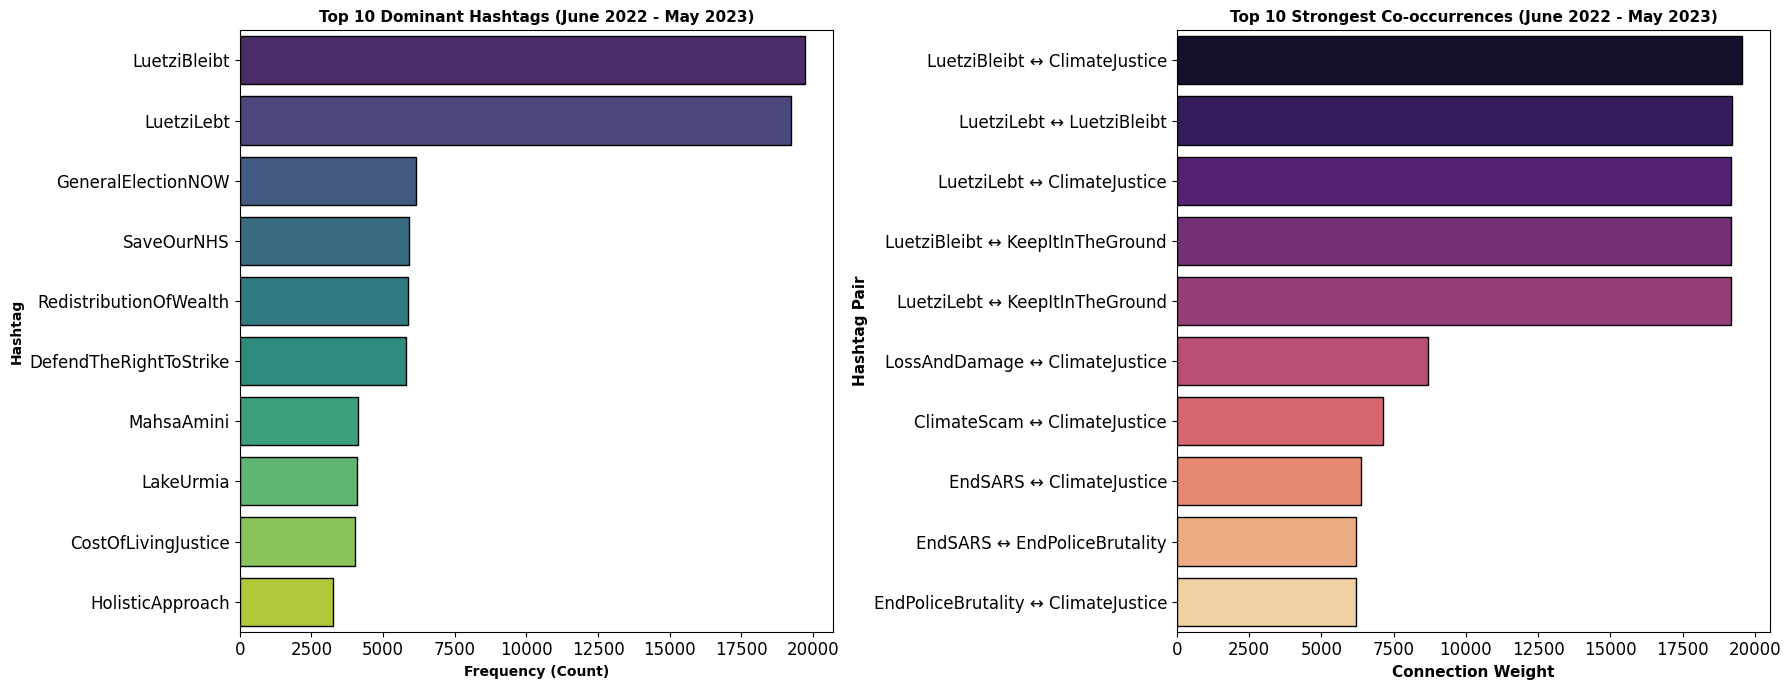


--- Network Data Summary (June '22 - May '23) ---
Top Node: #LuetziBleibt (Freq: 19716)
Strongest Edge: LuetziBleibt ↔ ClimateJustice (Weight: 19563)


In [ ]:
nodes_path = '/content/drive/MyDrive/SMA_Das_Biswas_Gul/Climate_Security_Datasets/nodes_June2022toMay2023_FINAL.csv'
edges_path = '/content/drive/MyDrive/SMA_Das_Biswas_Gul/Climate_Security_Datasets/edges_June2022toMay2023_FINAL.csv'
df_nodes = pd.read_csv(nodes_path)
df_edges = pd.read_csv(edges_path)

# For Nodes Frequency
if 'frequency' in df_nodes.columns:
    df_nodes['frequency'] = pd.to_numeric(df_nodes['frequency'], errors='coerce').fillna(0)

# For Edges Weight
weight_col = 'Weight' if 'Weight' in df_edges.columns else 'weight'
if weight_col in df_edges.columns:
    df_edges[weight_col] = pd.to_numeric(df_edges[weight_col], errors='coerce').fillna(0)
    # Standardize column name to 'Weight'
    df_edges.rename(columns={weight_col: 'Weight'}, inplace=True)

# Use 'Label' if available, otherwise fallback to 'Id'
label_col = 'Id' # Default
if 'Label' in df_nodes.columns:
    label_col = 'Label'
    df_nodes['Label'] = df_nodes['Label'].replace('Unknown', pd.NA)
    df_nodes['Label'] = df_nodes['Label'].fillna(df_nodes['Id'])


fig, axes = plt.subplots(1, 2, figsize=(18, 7))
sns.set_style("whitegrid")

# Top 10 Hashtags (Nodes)
# Sorting by frequency
top_nodes = df_nodes.sort_values(by='frequency', ascending=False).head(10)
sns.barplot(x='frequency', y=label_col, data=top_nodes, palette='viridis', edgecolor='black', ax=axes[0])
axes[0].set_title('Top 10 Dominant Hashtags (June 2022 - May 2023)', fontsize=11, fontweight='bold')

# Axis 0 Labels and Ticks
axes[0].set_xlabel('Frequency (Count)', fontsize=10, fontweight='bold')
axes[0].set_ylabel('Hashtag', fontsize=10, fontweight='bold')
axes[0].tick_params(axis='x', labelsize=12)
axes[0].tick_params(axis='y', labelsize=12)

# Top 10 Connections (Edges)
# Check if Source/Target columns exist
if 'Source' in df_edges.columns and 'Target' in df_edges.columns:
    # Create labels for connections
    df_edges['Connection'] = df_edges['Source'].astype(str) + " ↔ " + df_edges['Target'].astype(str)
    # Sorting by Weight
    top_edges = df_edges.sort_values(by='Weight', ascending=False).head(10)
    sns.barplot(x='Weight', y='Connection', data=top_edges, palette='magma', edgecolor='black', ax=axes[1])
    axes[1].set_title('Top 10 Strongest Co-occurrences (June 2022 - May 2023)', fontsize=11, fontweight='bold')
    axes[1].set_xlabel('Connection Weight', fontsize=11, fontweight='bold')
    axes[1].set_ylabel('Hashtag Pair', fontsize=11, fontweight='bold')
    axes[1].tick_params(axis='x', labelsize=12)
    axes[1].tick_params(axis='y', labelsize=12)
else:
    axes[1].text(0.5, 0.5, "Source/Target columns missing!", ha='center', fontsize=14, color='red')
for ax in axes:
    for label in ax.get_xticklabels() + ax.get_yticklabels():
        label.set_fontweight('normal')

plt.tight_layout()
plt.show()

# Print Summary
print("\n--- Network Data Summary (June '22 - May '23) ---")
if not top_nodes.empty:
    print(f"Top Node: #{top_nodes.iloc[0][label_col]} (Freq: {top_nodes.iloc[0]['frequency']})")
if not top_edges.empty:
    print(f"Strongest Edge: {top_edges.iloc[0]['Connection']} (Weight: {top_edges.iloc[0]['Weight']})")

Edge Weight Distribution

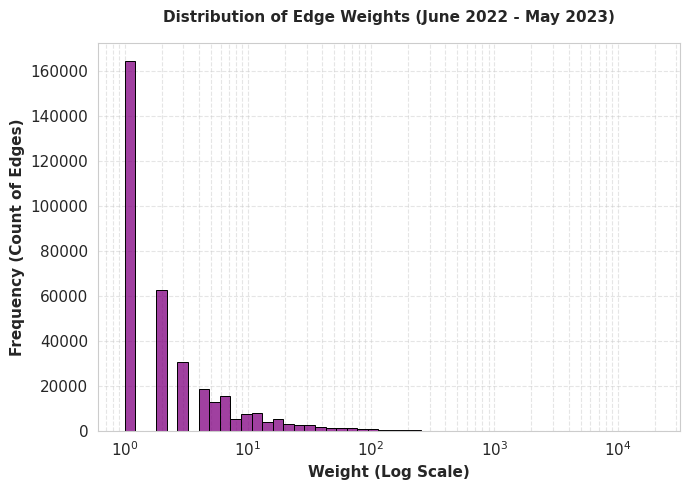


Max Edge Weight: 19563
Most Common Weight: 1


In [ ]:
edges_path = '/content/drive/MyDrive/SMA_Das_Biswas_Gul/Climate_Security_Datasets/edges_June2022toMay2023_FINAL.csv'
df_edges = pd.read_csv(edges_path)

# Handle potential case sensitivity (Weight vs weight)
weight_col = 'Weight' if 'Weight' in df_edges.columns else 'weight'

if weight_col in df_edges.columns:
    # Standardize column name to 'Weight'
    df_edges.rename(columns={weight_col: 'Weight'}, inplace=True)
    # Ensure numeric type (Convert strings to numbers if necessary)
    df_edges['Weight'] = pd.to_numeric(df_edges['Weight'], errors='coerce')
    # Filter out zero or negative values
    plot_data = df_edges[df_edges['Weight'] > 0].copy()
else:
    plot_data = pd.DataFrame({'Weight': []}) # Empty DataFrame to prevent crash
    print("Error: 'Weight' column not found!")

plt.figure(figsize=(7, 5))
sns.set_style("whitegrid")

# Edge Weight Distribution
if not plot_data.empty:
    sns.histplot(plot_data['Weight'], bins=50, log_scale=(True, False), color='purple', edgecolor='black')
    plt.title('Distribution of Edge Weights (June 2022 - May 2023)', fontsize=11, fontweight='bold', pad=15)
    plt.xlabel('Weight (Log Scale)', fontsize=11, fontweight='bold')
    plt.ylabel('Frequency (Count of Edges)', fontsize=11, fontweight='bold')
    plt.xticks(fontsize=11, fontweight='normal')
    plt.yticks(fontsize=11, fontweight='normal')

    plt.grid(True, which="both", ls="--", alpha=0.5)
else:
    plt.text(0.5, 0.5, "No valid weight data found!", ha='center', fontsize=14, color='red')

plt.tight_layout()
plt.show()

# Print Stats
if not plot_data.empty:
    print(f"\nMax Edge Weight: {plot_data['Weight'].max()}")
    print(f"Most Common Weight: {plot_data['Weight'].mode()[0]}")

### 1.4 Advanced Structural Analysis

In [ ]:
nodes_path = '/content/drive/MyDrive/SMA_Das_Biswas_Gul/Climate_Security_Datasets/nodes_June2022toMay2023_FINAL.csv'
edges_path = '/content/drive/MyDrive/SMA_Das_Biswas_Gul/Climate_Security_Datasets/edges_June2022toMay2023_FINAL.csv'
df_nodes = pd.read_csv(nodes_path, dtype={'Id': str, 'Label': str})
df_edges = pd.read_csv(edges_path, dtype={'Source': str, 'Target': str})

# Construct the Graph (Undirected)
G = nx.from_pandas_edgelist(
    df_edges,
    source='Source',
    target='Target',
    edge_attr='Weight',
    create_using=nx.Graph()
)
print(f"Graph Construction Complete.")
print(f"Nodes: {G.number_of_nodes()}")
print(f"Edges: {G.number_of_edges()}")

Graph Construction Complete.
Nodes: 41188
Edges: 353192


k-CORE DECOMPOSITION (HIERARCHY ANALYSIS)


Max k-Core Shell: 49
Size of Deepest Core: 250 hashtags
Examples: ['COP27', 'EnvironmentalJustice', 'GretaThunberg', 'ClimateCrisis', 'SocialJustice', 'youth', 'ClimateAction', 'vegan', 'planetearth', 'ClimateRisk']


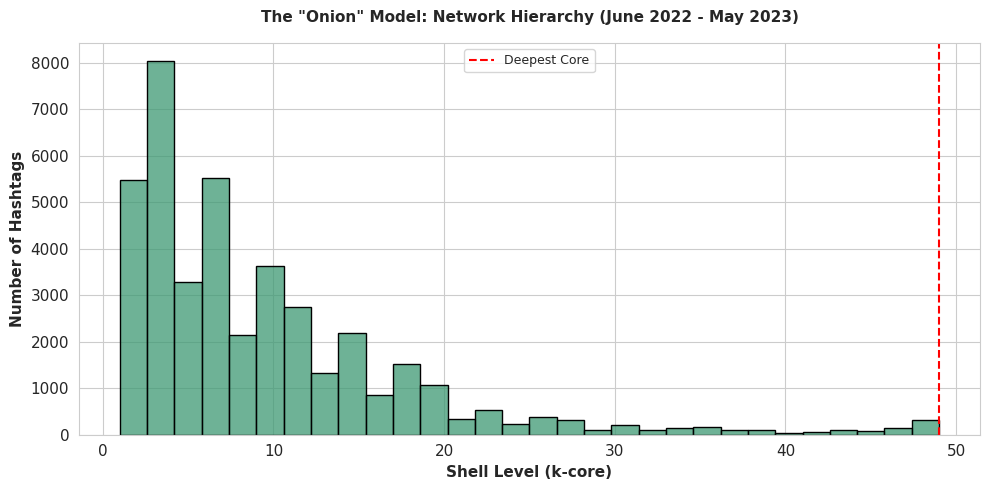

In [ ]:
G.remove_edges_from(nx.selfloop_edges(G))
core_numbers = nx.core_number(G)
max_k = max(core_numbers.values())
core_nodes = [node for node, k in core_numbers.items() if k == max_k]

print(f"\nMax k-Core Shell: {max_k}")
print(f"Size of Deepest Core: {len(core_nodes)} hashtags")
print(f"Examples: {core_nodes[:10]}")

plt.figure(figsize=(10, 5))
sns.histplot(list(core_numbers.values()), bins=30, color='#3d9973', edgecolor='black')
plt.title('The "Onion" Model: Network Hierarchy (June 2022 - May 2023)', fontsize=11, fontweight='bold', pad=15)
plt.xlabel('Shell Level (k-core)', fontsize=11, fontweight='bold')
plt.ylabel('Number of Hashtags', fontsize=11, fontweight='bold')
plt.xticks(fontsize=11, fontweight='normal')
plt.yticks(fontsize=11, fontweight='normal')
plt.axvline(max_k, color='red', linestyle='--', label='Deepest Core')
plt.legend(prop={'size': 9, 'weight': 'normal'})
plt.tight_layout()
plt.show()

Deep Core Network Visualization

Visualizing 6874 nodes (k-core > 15)


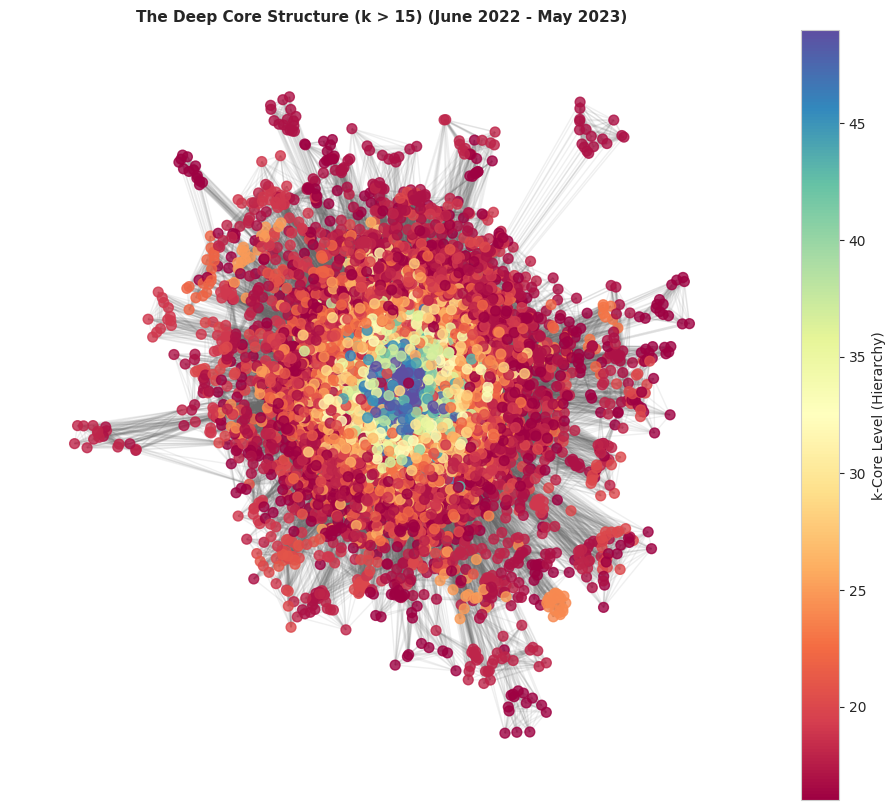

In [ ]:
# Filter Settings
filter_threshold = 15
sub_nodes = [n for n, k in core_numbers.items() if k > filter_threshold]
k_sub = G.subgraph(sub_nodes)
print(f"Visualizing {len(sub_nodes)} nodes (k-core > {filter_threshold})")

if len(sub_nodes) > 0:
    pos = nx.spring_layout(k_sub, seed=42)
    node_colors = [core_numbers[n] for n in k_sub.nodes()]
    plt.figure(figsize=(12, 10))
    ax = plt.gca()
    nodes = nx.draw_networkx_nodes(k_sub, pos,
                                   node_size=50,
                                   node_color=node_colors,
                                   cmap=plt.cm.Spectral,
                                   alpha=0.8,
                                   ax=ax)
    nx.draw_networkx_edges(k_sub, pos, alpha=0.1, edge_color='dimgray', ax=ax)
    vmin = min(node_colors)
    vmax = max(node_colors)
    sm = plt.cm.ScalarMappable(cmap=plt.cm.Spectral, norm=plt.Normalize(vmin=vmin, vmax=vmax))
    sm.set_array([])
    plt.colorbar(sm, ax=ax, label='k-Core Level (Hierarchy)')
    plt.title(f'The Deep Core Structure (k > {filter_threshold}) (June 2022 - May 2023)', fontsize=11, fontweight='bold')
    plt.axis('off')
    plt.show()
else:
    print(f"No nodes found with k-core > {filter_threshold}.")

### 1.5 Community and Topic Discovery

Louvain Community Detection

In [ ]:
random.seed(42)
np.random.seed(42)

# --- Louvain Community Detection ---
partition = community_louvain.best_partition(G, weight='Weight', random_state=42)
modularity_score = community_louvain.modularity(partition, G, weight='Weight')
print(f"Modularity Score (Q): {modularity_score:.4f}")

# --- Organize Data ---
# Create a dataframe to map Hashtags to their Topic (Community ID)
topic_df = pd.DataFrame.from_dict(partition, orient='index', columns=['Community_ID'])
topic_df.index.name = 'Id'

# Merge with df_nodes
topic_df = topic_df.reset_index().merge(df_nodes[['Id', 'frequency']], on='Id', how='left')

# --- Display the Top 10 Topics ---
top_topics = topic_df['Community_ID'].value_counts().head(10).index

print(f"Total Communities Discovered: {len(set(partition.values()))}")
print("Top 10 Dominant Topics (Communities) - June 2022 to May 2023:")

for cid in top_topics:
    count = len(topic_df[topic_df['Community_ID']==cid])
    print(f"\n--- TOPIC {cid} (Size: {count} hashtags) ---")

    # Show the top 10 most frequent hashtags in this topic to identify its theme
    keywords = topic_df[topic_df['Community_ID']==cid].sort_values(by='frequency', ascending=False).head(10)['Id'].tolist()
    print(f"Keywords: {keywords}")

output_topic_path = '/content/drive/MyDrive/SMA_Das_Biswas_Gul/Climate_Security_Datasets/sna_communities_June2022toMay2023.csv'
topic_df.to_csv(output_topic_path, index=False)

print(f"\n-> Results saved to: {output_topic_path}")

Modularity Score (Q): 0.5398
Total Communities Discovered: 120
Top 10 Dominant Topics (Communities) - June 2022 to May 2023:

--- TOPIC 2 (Size: 10925 hashtags) ---
Keywords: ['MahsaAmini', 'LakeUrmia', 'EarthDay2023', 'BlackHistoryMonth', 'climateJustice', 'BrazilianPolitics', 'mapoli', 'EJFriday', 'EnvHum', 'InflationReductionAct']

--- TOPIC 0 (Size: 8549 hashtags) ---
Keywords: ['WeAreNotYetDefeated', 'GlobalDayofAction', 'climatemobility', 'nonewcoal', 'MoveBeyondCoal', 'DebatirYRenovar', 'EcologistasEnSharm', 'CJPavilionCOP27', 'Actonclimate', 'AfricanClimateCaravan']

--- TOPIC 1 (Size: 5890 hashtags) ---
Keywords: ['Trending', 'DigitalCurrency', 'vaccinegenocide', 'LossAndDamages', 'ClimateReparations', 'TrendingNow', 'ModernSlavery', 'PlantATree', 'pacja', 'climatescam']

--- TOPIC 4 (Size: 5686 hashtags) ---
Keywords: ['LuetziBleibt', 'LuetziLebt', 'FreeAlaa', 'WhatHasChanged', 'FreeThemAll', 'PACJA', 'BBZLeadingClimateJustice', 'TheBigOne', 'ICJAO4Climate', 'BanPrivateJets']

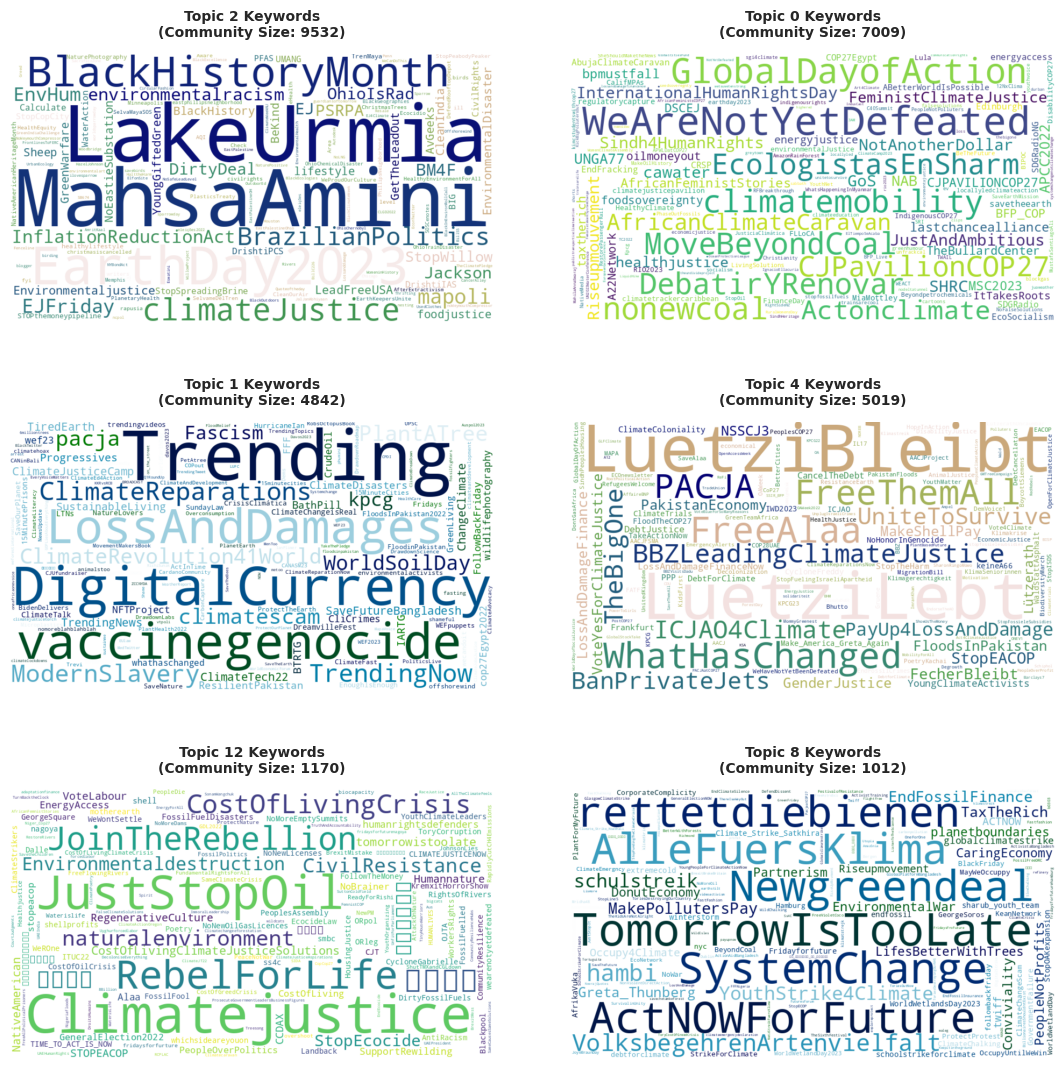

In [ ]:
plt.rcParams.update({
    'font.size': 14,
    'font.weight': 'bold',
    'figure.facecolor': 'white'
})

top_6_cid = topic_df['Community_ID'].value_counts().head(6).index

color_maps = ['gist_earth', 'viridis', 'ocean',
              'gist_earth', 'viridis', 'ocean']

fig, axes = plt.subplots(3, 2, figsize=(12, 12))

for i, cid in enumerate(top_6_cid):
    row, col = divmod(i, 2)

    comm_data = topic_df[topic_df['Community_ID'] == cid].copy()
    comm_data['frequency'] = comm_data['frequency'].fillna(0)
    comm_data = comm_data[comm_data['frequency'] > 0]

    if not comm_data.empty:
        word_freq = dict(zip(comm_data['Id'], comm_data['frequency']))

        wc = WordCloud(
            width=900, height=500,
            background_color='white',
            colormap=color_maps[i],
            contour_width=3,
            contour_color='steelblue',
            max_words=150,
            prefer_horizontal=0.8
        ).generate_from_frequencies(word_freq)

        axes[row, col].imshow(wc, interpolation='bilinear')
        axes[row, col].set_title(
            f'Topic {cid} Keywords\n(Community Size: {len(comm_data)})',
            fontsize=10, fontweight='bold', pad=12
        )
        axes[row, col].axis('off')
    else:
        axes[row, col].text(
            0.5, 0.5, f"No valid data for Topic {cid}",
            ha='center', va='center', fontsize=12
        )
        axes[row, col].axis('off')

plt.tight_layout(pad=4.0)
plt.show()


### 1.6 Network Influence Analysis

Centrality Calculation (Degree vs. Betweenness)

In [ ]:
# 1. Calculate Degree Centrality (Popularity)
degree_cent = nx.degree_centrality(G)

# --- PREPARE INVERSE WEIGHT FOR BETWENNESS ---
# Because NetworkX treats weight as distance,
for u, v, d in G.edges(data=True):
    d['inv_weight'] = 1 / d['Weight'] if d['Weight'] > 0 else 0
N = G.number_of_nodes()
k_sample = int(0.3 * N)
print(f"Sampling {k_sample} nodes for Betweenness Centrality approximation.")

# 2. Calculate Betweenness Centrality (Bridging Influence)
betweenness_cent = nx.betweenness_centrality(
    G,
    k=k_sample,              # Sampling for scalability
    weight='inv_weight',     # Use inverse weight (correct interpretation)
    normalized=True,
    seed=42                  # Reproducibility
)

cent_df = pd.DataFrame({
    'Hashtag': list(G.nodes()),
    'Degree_Centrality': [degree_cent[n] for n in G.nodes()],
    'Betweenness_Centrality': [betweenness_cent[n] for n in G.nodes()]
})
output_cent_path = '/content/drive/MyDrive/SMA_Das_Biswas_Gul/Climate_Security_Datasets/sna_centrality_June2022toMay2023.csv'
cent_df.to_csv(output_cent_path, index=False)
print(f"\nCentrality data saved to: {output_cent_path}")


Sampling 12356 nodes for Betweenness Centrality approximation.

Centrality data saved to: /content/drive/MyDrive/SMA_Project_Material/Climate_Security_Datasets/sna_centrality_June2022toMay2023.csv


In [ ]:
import pandas as pd
cent_df = pd.read_csv('/content/drive/MyDrive/SMA_Das_Biswas_Gul/Climate_Security_Datasets/sna_centrality_June2022toMay2023.csv')
top_bridges = cent_df.sort_values(
    by='Betweenness_Centrality',
    ascending=False
).head(15)
print("\n--- Top 15 Bridging Hashtags (June 2022 - May 2023) ---")
print(top_bridges)



--- Top 15 Bridging Hashtags (June 2022 - May 2023) ---
                  Hashtag  Degree_Centrality  Betweenness_Centrality
46         ClimateJustice           0.494161                0.769933
3    EnvironmentalJustice           0.248816                0.285230
87            ClimateScam           0.043557                0.274115
68         climatejustice           0.203292                0.233679
29          ClimateCrisis           0.144050                0.168342
760         LossAndDamage           0.024984                0.165661
99   environmentaljustice           0.174618                0.162954
1                   COP27           0.108432                0.121094
82       ClimateEmergency           0.137349                0.084830
59                climate           0.094981                0.041394
39          ClimateAction           0.154175                0.029302
131     ClimateJusticeNow           0.049190                0.029098
109         climatechange           0.078714  

The Connector Paradox Visualization

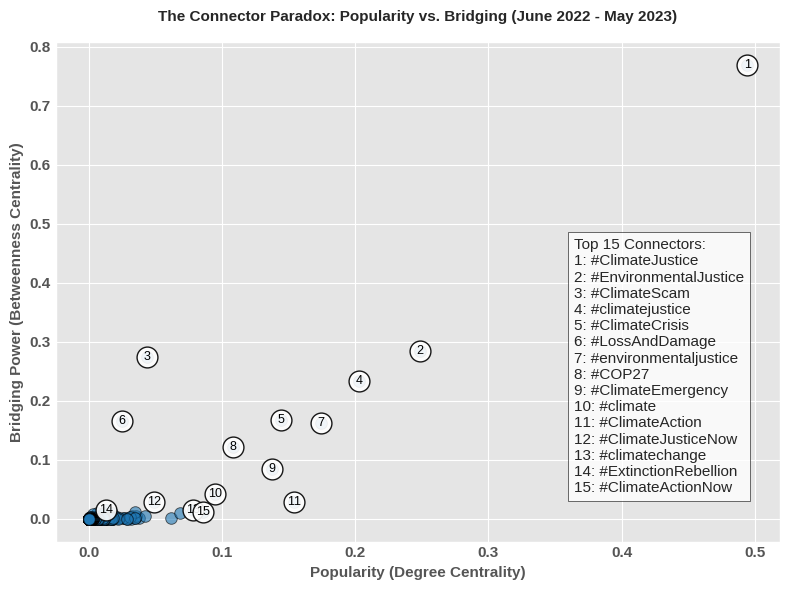

In [ ]:
# 1. Create the DataFrame of top connectors
top_connectors = cent_df.sort_values(by='Betweenness_Centrality', ascending=False).head(15)

plt.style.use('ggplot')
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=cent_df,
    x='Degree_Centrality',
    y='Betweenness_Centrality',
    alpha=0.6,
    color='#1F77B4',
    edgecolor='black',
    s=70
)
plt.title('The Connector Paradox: Popularity vs. Bridging (June 2022 - May 2023)',
    fontsize=11, fontweight='bold', pad=15
)
plt.xlabel('Popularity (Degree Centrality)', fontsize=11, fontweight='bold')
plt.ylabel('Bridging Power (Betweenness Centrality)', fontsize=11, fontweight='bold')
plt.xticks(fontsize=11, fontweight='bold')
plt.yticks(fontsize=11, fontweight='bold')
for i in range(len(top_connectors)):
    row = top_connectors.iloc[i]
    plt.plot(
        row['Degree_Centrality'],
        row['Betweenness_Centrality'],
        'o', markerfacecolor='white', markeredgecolor='black',
        markersize=15, alpha=0.9, zorder=4
    )
    plt.text(
        row['Degree_Centrality'],
        row['Betweenness_Centrality'],
        str(i+1),
        fontsize=9, weight='normal', color='black',
        ha='center', va='center', zorder=4
    )

legend_text = 'Top 15 Connectors:\n'
for i in range(len(top_connectors)):
    hashtag_name = top_connectors.iloc[i]['Hashtag']
    legend_text += f'{i+1}: #{hashtag_name}\n'

at = AnchoredText(
    legend_text.strip(), loc='lower right', prop=dict(size=11),
    frameon=True, bbox_to_anchor=(0.98, 0.05),
    bbox_transform=plt.gca().transAxes, borderpad=1
)
at.patch.set_facecolor('white')
at.patch.set_alpha(0.8)
plt.gca().add_artist(at)
plt.tight_layout()
plt.show()

### 1.7 Global Network Behavior

The Echo Chamber Test (Assortativity)

Assortativity Coefficient (r): -0.1089


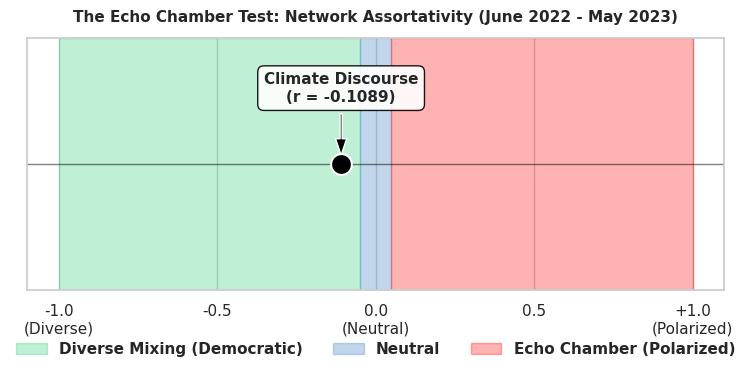

In [ ]:
try:
    r_value = nx.degree_assortativity_coefficient(G)
    print(f"Assortativity Coefficient (r): {r_value:.4f}")
except Exception as e:
    print(f"Error calculating assortativity: {e}")
    r_value = 0

plt.figure(figsize=(9, 4))
plt.axhline(y=0, color='black', linestyle='-', linewidth=1, alpha=0.5)
plt.xlim(-1.1, 1.1)
plt.ylim(-1, 1)
plt.axvspan(-1, -0.05, color='#2ecc71', alpha=0.3, label='Diverse Mixing (Democratic)')
plt.axvspan(-0.05, 0.05, color='#3778bf', alpha=0.3, label='Neutral')
plt.axvspan(0.05, 1, color='red', alpha=0.3, label='Echo Chamber (Polarized)')
plt.plot(r_value, 0, marker='o', markersize=15, color='black',
         markeredgecolor='white', markeredgewidth=1.5, zorder=5)

plt.annotate(
    f'Climate Discourse\n(r = {r_value:.4f})',
    xy=(r_value, 0.05),
    xytext=(r_value, 0.5),
    arrowprops=dict(facecolor='black', shrink=0.05, width=1.5, headwidth=8),
    bbox=dict(boxstyle="round,pad=0.4", fc="white", ec="black", alpha=0.9),
    ha='center', fontsize=11, fontweight='bold'
)

plt.title('The Echo Chamber Test: Network Assortativity (June 2022 - May 2023)', fontsize=11, fontweight='bold', pad=12)
plt.xticks([-1, -0.5, 0, 0.5, 1], ['-1.0\n(Diverse)', '-0.5', '0.0\n(Neutral)', '0.5', '+1.0\n(Polarized)'], fontsize=11, fontweight='normal')
plt.yticks([])
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=3, frameon=False, prop={'size': 11, 'weight': 'bold'})
plt.subplots_adjust(bottom=0.25)
plt.show()

Topic Assortativity (r_topic): 0.4431


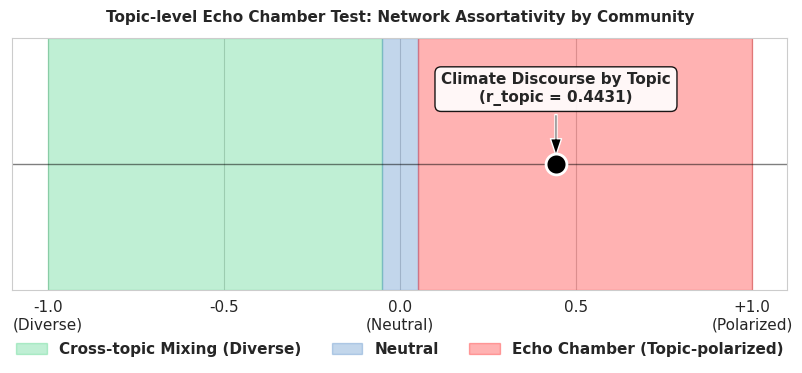

In [ ]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

# --- 1. Load the topic CSV saved earlier ---
topic_csv_path = '/content/drive/MyDrive/SMA_Das_Biswas_Gul/Climate_Security_Datasets/sna_communities_June2022toMay2023.csv'
topic_df = pd.read_csv(topic_csv_path)

# --- 2. Attach topic as node attribute in the graph ---
# Ensure your graph G is already constructed
nx.set_node_attributes(G, pd.Series(topic_df.set_index('Id')['Community_ID']).to_dict(), 'topic')

# --- 3. Calculate topic-level assortativity ---
try:
    r_topic = nx.attribute_assortativity_coefficient(G, 'topic')
    print(f"Topic Assortativity (r_topic): {r_topic:.4f}")
except Exception as e:
    print(f"Error calculating topic assortativity: {e}")
    r_topic = 0

# --- 4. Plot topic-level echo chamber ---
plt.figure(figsize=(10, 4))
plt.axhline(y=0, color='black', linestyle='-', linewidth=1, alpha=0.5)
plt.xlim(-1.1, 1.1)
plt.ylim(-1, 1)
plt.axvspan(-1, -0.05, color='#2ecc71', alpha=0.3, label='Cross-topic Mixing (Diverse)')
plt.axvspan(-0.05, 0.05, color='#3778bf', alpha=0.3, label='Neutral')
plt.axvspan(0.05, 1, color='red', alpha=0.3, label='Echo Chamber (Topic-polarized)')

plt.plot(r_topic, 0, marker='o', markersize=15, color='black',
         markeredgecolor='white', markeredgewidth=2, zorder=5)

plt.annotate(
    f'Climate Discourse by Topic\n(r_topic = {r_topic:.4f})',
    xy=(r_topic, 0.05),
    xytext=(r_topic, 0.5),
    arrowprops=dict(facecolor='black', shrink=0.05, width=1.5, headwidth=8),
    bbox=dict(boxstyle="round,pad=0.4", fc="white", ec="black", alpha=0.9),
    ha='center', fontsize=11, fontweight='bold'
)

plt.title('Topic-level Echo Chamber Test: Network Assortativity by Community', fontsize=11, fontweight='bold', pad=12)
plt.xticks([-1, -0.5, 0, 0.5, 1], ['-1.0\n(Diverse)', '-0.5', '0.0\n(Neutral)', '0.5', '+1.0\n(Polarized)'], fontsize=11, fontweight='normal')
plt.yticks([])
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=3, frameon=False, prop={'size': 11, 'weight': 'bold'})
plt.subplots_adjust(bottom=0.25)
plt.show()


### 1.8 Dynamic Cohesion Analysis

Temporal Evolution of Network Density

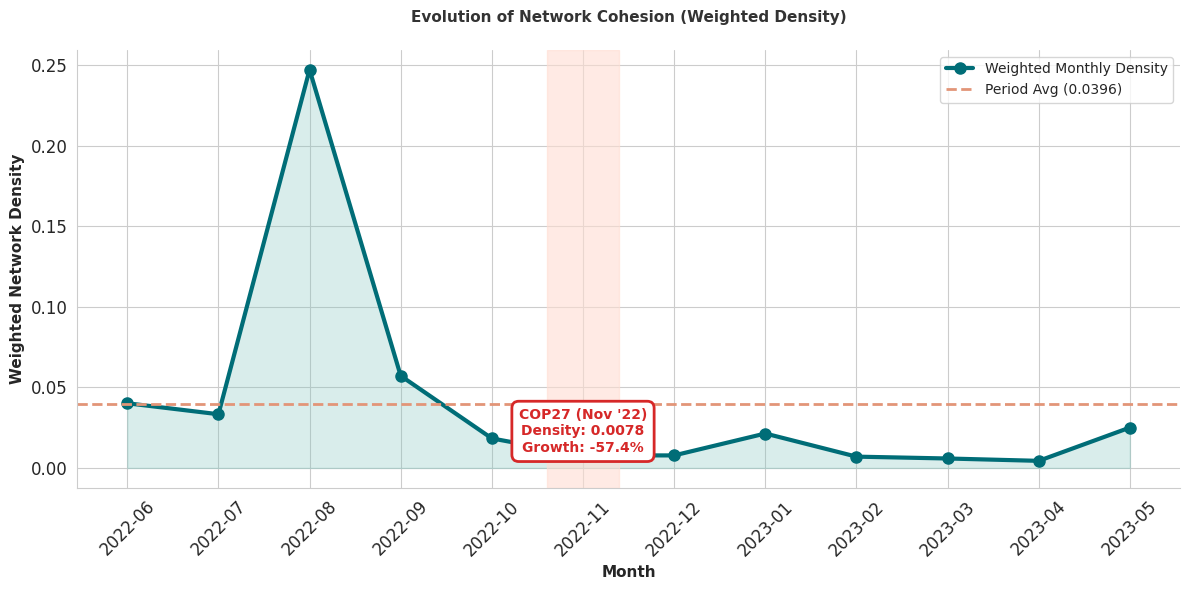


--- Statistical Summary ---
Period Average Density: 0.03965
COP27 (Nov) Growth: -57.40% compared to previous month


,Density
Month,
2022-06,0.040176
2022-07,0.033360
2022-08,0.247371
2022-09,0.057215
2022-10,0.018338
2022-11,0.007812
2022-12,0.007778
2023-01,0.021386
2023-02,0.007018


In [ ]:
edges_path = '/content/drive/MyDrive/SMA_Das_Biswas_Gul/Climate_Security_Datasets/edges_June2022toMay2023_FINAL.csv'
df_edges_dynamic = pd.read_csv(edges_path)
df_edges_dynamic['timestamp'] = pd.to_datetime(df_edges_dynamic['timestamp'])

# Define Custom Weighted Density Function
# (Standard nx.density doesn't consider weights, so we use this)
def get_weighted_density(graph):
    n = len(graph)
    if n <= 1:
        return 0
    # Sum of weights (default to 1 if missing)
    total_weight = sum(d.get('Weight', 1) for u, v, d in graph.edges(data=True))
    # Possible edges for undirected graph
    possible_edges = n * (n - 1) / 2
    return total_weight / possible_edges

# Calculate Monthly Density
monthly_density = {}

# Grouping by Month
for period, group in df_edges_dynamic.groupby(df_edges_dynamic['timestamp'].dt.to_period('M')):
    # Note: Added edge_attr='Weight' to load weights
    G_temp = nx.from_pandas_edgelist(group, 'Source', 'Target', edge_attr='Weight')

    # Use the custom function instead of nx.density
    monthly_density[str(period)] = get_weighted_density(G_temp)

# DataFrame Preparation
density_df = pd.DataFrame.from_dict(monthly_density, orient='index', columns=['Density'])
density_df.index.name = 'Month'

plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")
x_indices = range(len(density_df))
plt.plot(x_indices, density_df['Density'], color='#006d77', linewidth=3, marker='o', markersize=8, label='Weighted Monthly Density')
plt.fill_between(x_indices, density_df['Density'], color='#83c5be', alpha=0.3)
avg_density = density_df['Density'].mean()
plt.axhline(y=avg_density, color='#e29578', linestyle='--', linewidth=2, label=f'Period Avg ({avg_density:.4f})')

# Highlight COP27 (November 2022)
try:
    nov_idx = density_df.index.get_loc('2022-11')
    nov_val = density_df.loc['2022-11', 'Density']

    # Calculate growth from previous month
    if nov_idx > 0:
        prev_val = density_df.iloc[nov_idx-1]['Density']
        growth = ((nov_val - prev_val) / prev_val) * 100
    else:
        growth = 0
    plt.axvspan(nov_idx - 0.4, nov_idx + 0.4, color='#ffddd2', alpha=0.6)
    label_text = f"COP27 (Nov '22)\nDensity: {nov_val:.4f}\nGrowth: {growth:+.1f}%"
    plt.annotate(label_text,
                 xy=(nov_idx, nov_val),
                 xytext=(nov_idx, nov_val * 1.3),
                 arrowprops=dict(facecolor='#d62828', shrink=0.05, width=2),
                 bbox=dict(boxstyle="round,pad=0.5", fc="white", ec="#d62828", lw=2),
                 ha='center', fontsize=10, fontweight='bold', color='#d62828')
except (KeyError, IndexError):
    print("November 2022 not found in data or insufficient months for comparison.")

plt.title('Evolution of Network Cohesion (Weighted Density)', fontsize=11, fontweight='bold', color='#333333', pad=20)
plt.ylabel('Weighted Network Density', fontsize=11, fontweight='bold')
plt.xlabel('Month', fontsize=11, fontweight='bold')

# Setting ticks to normal font
plt.xticks(ticks=x_indices, labels=density_df.index, rotation=45, fontsize=12, fontweight='normal')
plt.yticks(fontsize=12, fontweight='normal')

plt.legend(loc='upper right', prop={'size': 10, 'weight': 'normal'})
sns.despine()
plt.tight_layout()
plt.show()

# Summary Statistics
print("\n--- Statistical Summary ---")
print(f"Period Average Density: {avg_density:.5f}")
try:
    print(f"COP27 (Nov) Growth: {growth:+.2f}% compared to previous month")
except:
    pass
display(density_df)

## 2. Social Content Analysis
This part analyzes pre-calculated sentiment scores (based on the NRC Emotion Lexicon) associated with hashtags. It compares these scores between Global North and South (using T-tests), tracks emotional shifts over time with Rolling Averages, calculates the Volatility Index, and uses Spearman’s Correlation to link discussion volume with sentiment.

### 2.1 Annotated Content Data Analysis and Pre-processing

In [ ]:
import pandas as pd
import numpy as np

file_path_sca = '/content/drive/MyDrive/SMA_Das_Biswas_Gul/Climate_Security_Datasets/cs_tweets_annotated.csv'
df_sca = pd.read_csv(file_path_sca, dtype={'dataset_CS$id': str})

print(f"Loaded Rows: {len(df_sca)}")
print("\n--- Missing Values (Before Preprocessing) ---")
print(df_sca.isnull().sum())
print("\n--- Data Info ---")
df_sca.info()

Loaded Rows: 636379

--- Missing Values (Before Preprocessing) ---
dataset_CS$id                          0
hashtags_net$year                      0
hashtags_net$hashtags             122349
dataset_CSTESTE$sentiment_nrc      17421
dataset_CS$countries_mentioned    511756
dtype: int64

--- Data Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 636379 entries, 0 to 636378
Data columns (total 5 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   dataset_CS$id                   636379 non-null  object 
 1   hashtags_net$year               636379 non-null  object 
 2   hashtags_net$hashtags           514030 non-null  object 
 3   dataset_CSTESTE$sentiment_nrc   618958 non-null  float64
 4   dataset_CS$countries_mentioned  124623 non-null  object 
dtypes: float64(1), object(4)
memory usage: 24.3+ MB


In [ ]:
START_DATE = '2022-06-01'
END_DATE = '2023-05-31'

# 1. Convert Date Column
df_sca['hashtags_net$year'] = pd.to_datetime(df_sca['hashtags_net$year'], errors='coerce')

# 2. Filter for New Timeframe
df_sca_filtered = df_sca[
    (df_sca['hashtags_net$year'] >= START_DATE) &
    (df_sca['hashtags_net$year'] <= END_DATE)
].copy()

# 3. Simplify & Rename Columns
df_sca_filtered.rename(columns={
    'dataset_CS$id': 'tweet_id',
    'hashtags_net$year': 'hashtags_net_date',
    'hashtags_net$hashtags': 'hashtags',
    'dataset_CSTESTE$sentiment_nrc': 'sentiment_score',
    'dataset_CS$countries_mentioned': 'country'
}, inplace=True)

# 4. Handle Missing Values
df_sca_filtered['country'] = df_sca_filtered['country'].fillna('Unknown')
df_sca_filtered['hashtags'] = df_sca_filtered['hashtags'].fillna('NoHashtag').replace('', 'NoHashtag')
df_sca_filtered['sentiment_score'] = df_sca_filtered.groupby('hashtags')['sentiment_score'].transform(lambda x: x.fillna(x.mean()))
before_drop = len(df_sca_filtered)
df_sca_filtered = df_sca_filtered.dropna(subset=['sentiment_score'])

output_sca = '/content/drive/MyDrive/SMA_Das_Biswas_Gul/Climate_Security_Datasets/cs_annotated_June2022toMay2023_FINAL.csv'
df_sca_filtered.to_csv(output_sca, index=False)

# --- CHECK FINAL DATA ---
print(f"Filtered Rows ({START_DATE} to {END_DATE}): {len(df_sca_filtered)}")
print("\n--- Missing Values---")
print(df_sca_filtered.isnull().sum())
print(f"\n-> Saved to: {output_sca}")
print("\n--- First 5 Rows ---")
try:
    display(pretty(df_sca_filtered.head()))
except:
    display(df_sca_filtered.head())

Filtered Rows (2022-06-01 to 2023-05-31): 335112

--- Missing Values---
tweet_id             0
hashtags_net_date    0
hashtags             0
sentiment_score      0
country              0
dtype: int64

-> Saved to: /content/drive/MyDrive/SMA_Das_Biswas_Gul/Climate_Security_Datasets/cs_annotated_June2022toMay2023_FINAL.csv

--- First 5 Rows ---


,tweet_id,hashtags_net_date,hashtags,sentiment_score,country
0,1630370917695070000,2023-02-28 00:00:00,"environmentaljustice,humanities,envhum",3.000000,Unknown
1,1630369575962540000,2023-02-28 00:00:00,"pugetsound,environmentaljustice",-1.000000,Unknown
2,1630367295515110000,2023-02-28 00:00:00,"environmentaljustice,wtpBLUE,publichealth",-4.000000,Unknown
3,1630364230355410000,2023-02-28 00:00:00,"YouthLeadership,EndMalnutrition,FoodSecurity,climateJustice",2.000000,Unknown
4,1630360752027580000,2023-02-28 00:00:00,"EnergyJustice,PedalForPeopleAndPlanet,GenderJustice,ClimateJustice",1.000000,Unknown


### 2.2 Descriptive Sentiment & Volume Analysis

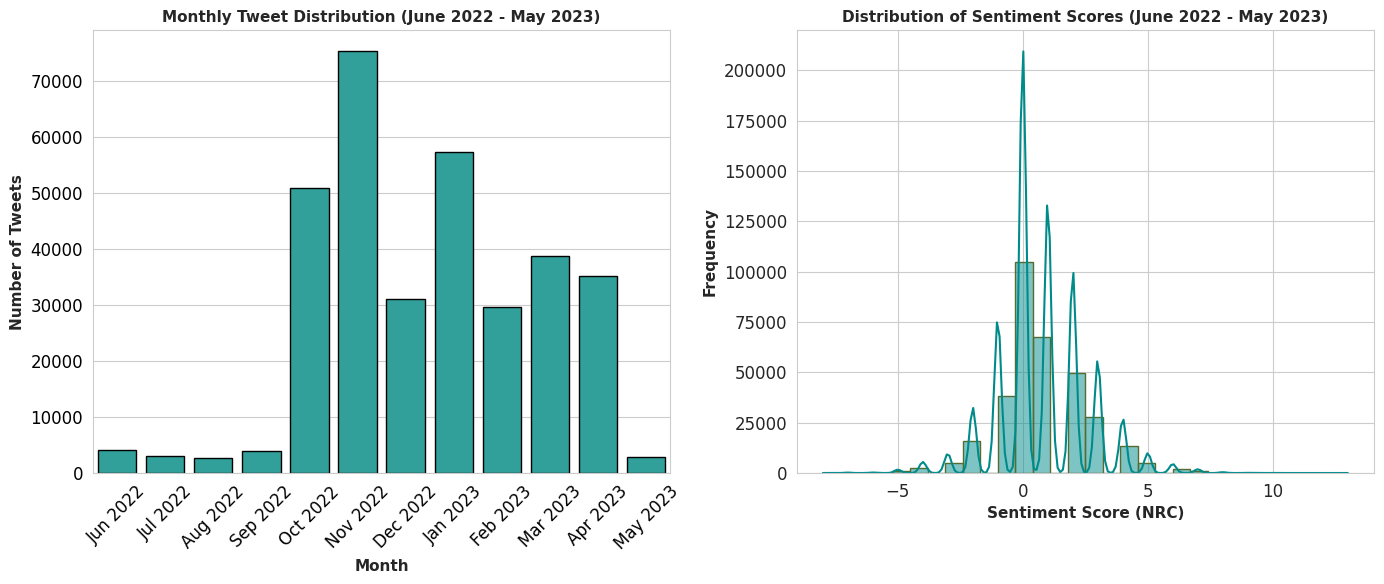

In [ ]:
sca_path = '/content/drive/MyDrive/SMA_Das_Biswas_Gul/Climate_Security_Datasets/cs_annotated_June2022toMay2023_FINAL.csv'
df_sca = pd.read_csv(sca_path)

# Convert Date Column
df_sca['hashtags_net_date'] = pd.to_datetime(df_sca['hashtags_net_date'])
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sns.set(style="whitegrid")

# Monthly Tweet Volume
monthly_counts = df_sca.resample('M', on='hashtags_net_date').size()
month_labels = monthly_counts.index.strftime('%b %Y')
sns.barplot(x=month_labels, y=monthly_counts.values, color='lightseagreen', edgecolor='black', ax=axes[0])
axes[0].set_title('Monthly Tweet Distribution (June 2022 - May 2023)', fontsize=11, fontweight='bold')

axes[0].set_xlabel('Month', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Number of Tweets', fontsize=11, fontweight='bold')
axes[0].tick_params(axis='both', which='major', labelsize=12, labelcolor='black')
for label in axes[0].get_xticklabels():
    label.set_rotation(45)
    label.set_fontweight('normal')
for label in axes[0].get_yticklabels():
    label.set_fontweight('normal')

# Sentiment Score Distribution
sentiment_col = 'sentiment_score'
if sentiment_col in df_sca.columns:
    sns.histplot(df_sca[sentiment_col], bins=30, kde=True, color='darkcyan', edgecolor='darkolivegreen', ax=axes[1])
    axes[1].set_title('Distribution of Sentiment Scores (June 2022 - May 2023)', fontsize=11, fontweight='bold')

    # Update fonts for Axis 1
    axes[1].set_xlabel('Sentiment Score (NRC)', fontsize=11, fontweight='bold')
    axes[1].set_ylabel('Frequency', fontsize=11, fontweight='bold')
    axes[1].tick_params(axis='x', labelsize=12)
    axes[1].tick_params(axis='y', labelsize=12)
else:
    print(f"Column '{sentiment_col}' not found for plotting.")

plt.tight_layout()
plt.show()

### 2.3 Regional Disparity Analysis (Global North vs. South)

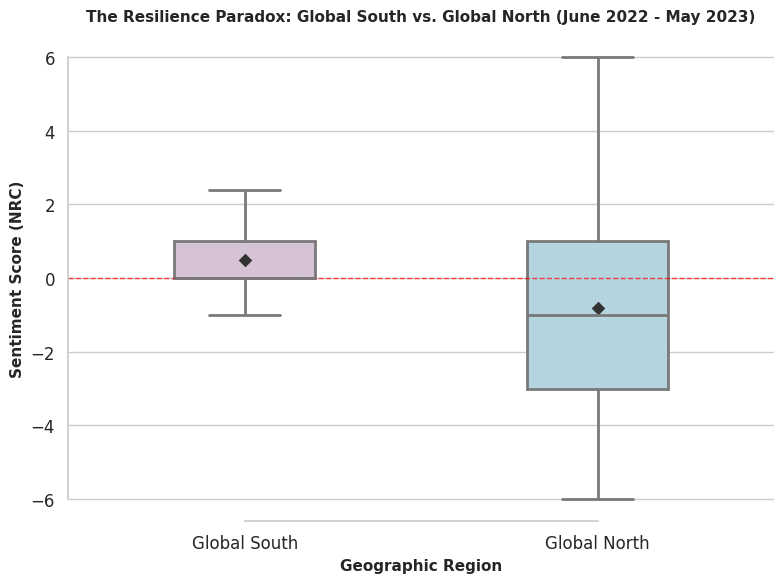


--- Regional Sentiment Summary ---


,count,mean,std,Median
Region,,,,
Global North,1533.0,-0.808197,2.383811,-1.0
Global South,71456.0,0.485414,1.591568,0.0



--- Statistical Significance (T-Test) ---
T-statistic: -21.1464
P-value: 1.7489e-87


In [ ]:
from scipy.stats import ttest_ind

sca_path = '/content/drive/MyDrive/SMA_Das_Biswas_Gul/Climate_Security_Datasets/cs_annotated_June2022toMay2023_FINAL.csv'
df_geo = pd.read_csv(sca_path)

# Global North List
global_north = [
    'United States', 'USA', 'United Kingdom', 'UK', 'Canada', 'Germany', 'France',
    'Australia', 'Italy', 'Spain', 'Netherlands', 'Sweden', 'Norway', 'Denmark',
    'Belgium', 'Switzerland', 'Austria', 'Finland', 'Ireland', 'New Zealand', 'Japan',
    'Scotland', 'England', 'Wales',
    'Russia', 'Poland', 'Portugal', 'Greece', 'Iceland', 'Luxembourg', 'Israel',
    'Czech Republic', 'Hungary', 'South Korea', 'Singapore', 'Estonia', 'Latvia', 'Lithuania'
]

def classify_region(country_str):
    if pd.isna(country_str) or str(country_str).strip().lower() == 'unknown':
        return 'Unknown'
    country_list = [c.strip().lower() for c in str(country_str).split(',')]
    north_list_lower = [gn.lower() for gn in global_north]
    for c in country_list:
        if c in north_list_lower:
            return 'Global North'
    return 'Global South'

df_geo['Region'] = df_geo['country'].apply(classify_region)
df_geo_filtered = df_geo[df_geo['Region'] != 'Unknown'].copy()

plt.figure(figsize=(8, 6))
sns.set_style("whitegrid")
my_palette = {'Global North': 'lightblue', 'Global South': 'thistle'}

sns.boxplot(x='Region', y='sentiment_score', data=df_geo_filtered,
            hue='Region', palette=my_palette, legend=False,
            width=0.4, linewidth=2, showfliers=False)

sns.pointplot(x='Region', y='sentiment_score', data=df_geo_filtered,
              estimator='mean', color='#333333',
              markers="D", scale=0.9, join=False, errorbar=None)

plt.title('The Resilience Paradox: Global South vs. Global North (June 2022 - May 2023)',
          fontsize=11, fontweight='bold', pad=10)
plt.ylabel('Sentiment Score (NRC)', fontsize=11, fontweight='bold')
plt.xlabel('Geographic Region', fontsize=11, fontweight='bold')
plt.xticks(fontsize=12, fontweight='normal')
plt.yticks(fontsize=12, fontweight='normal')
plt.axhline(0, color='red', linestyle='--', linewidth=1, alpha=0.7)
sns.despine(trim=True)
plt.tight_layout()
plt.show()

#  Statistical Summary & Test ---
print("\n--- Regional Sentiment Summary ---")
summary = df_geo_filtered.groupby('Region')['sentiment_score'].describe()[['count', 'mean', 'std', '50%']]
summary.rename(columns={'50%': 'Median'}, inplace=True)
display(summary)

# T-Test Calculation
north_scores = df_geo_filtered[df_geo_filtered['Region'] == 'Global North']['sentiment_score']
south_scores = df_geo_filtered[df_geo_filtered['Region'] == 'Global South']['sentiment_score']
t_stat, p_val = ttest_ind(north_scores, south_scores, equal_var=False)

print(f"\n--- Statistical Significance (T-Test) ---")
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_val:.4e}")

### 2.4 Temporal Sentiment Dynamics: The COP27 Effect

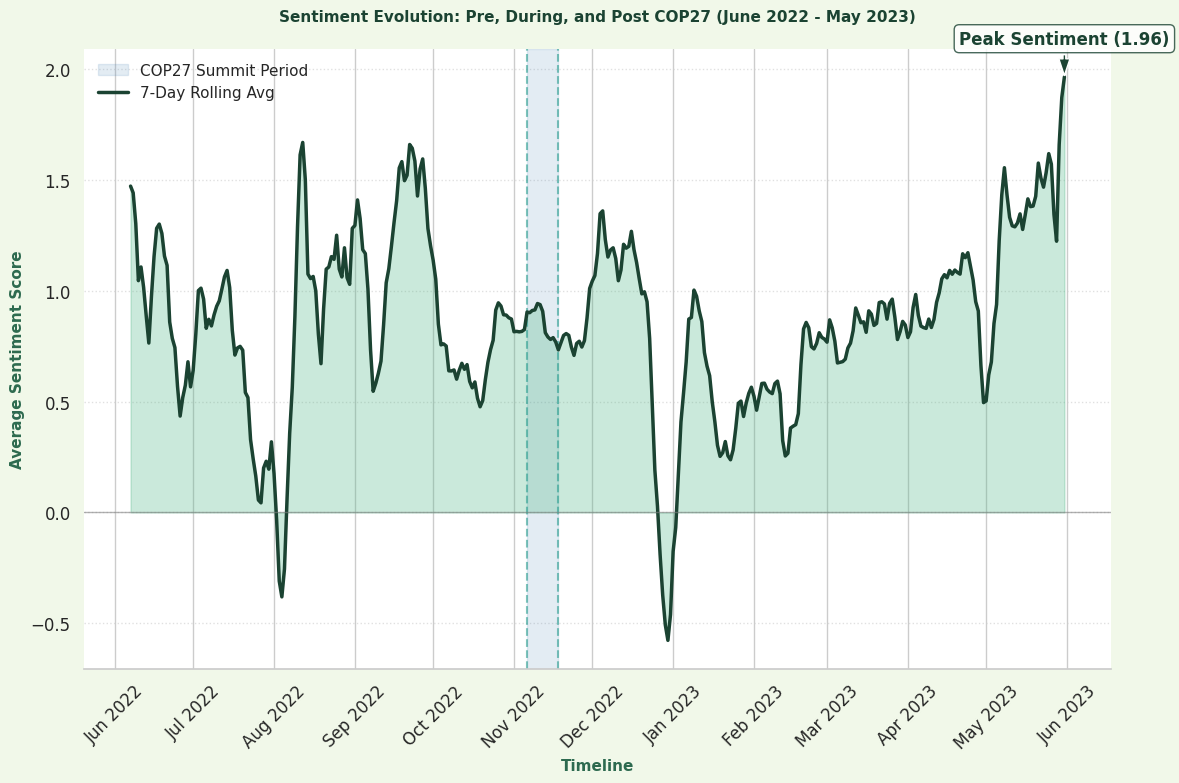


--- Statistical Proof: Sentiment Shift Across Phases ---


,count,mean,std
Phase,,,
Pre-Summit,74882.0,0.765312,1.794980
During COP27,47360.0,0.839220,1.694044
Post-Summit,212870.0,0.721026,1.755483


In [ ]:
import matplotlib.dates as mdates

sca_path = '/content/drive/MyDrive/SMA_Das_Biswas_Gul/Climate_Security_Datasets/cs_annotated_June2022toMay2023_FINAL.csv'
df = pd.read_csv(sca_path)

date_col = 'hashtags_net_date'
df[date_col] = pd.to_datetime(df[date_col])
df = df.sort_values(date_col)

# Define Phases
def define_phase(date):
    if date < pd.Timestamp('2022-11-06'):
        return 'Pre-Summit'
    elif date <= pd.Timestamp('2022-11-18'):
        return 'During COP27'
    else:
        return 'Post-Summit'
df['Phase'] = df[date_col].apply(define_phase)

# Daily mean
daily_sentiment = df.resample('D', on=date_col)['sentiment_score'].mean()

# --- (min_periods=7) ---
rolling_sentiment = daily_sentiment.rolling(window=7, min_periods=7).mean()

# --- Plotting ---
fig, ax = plt.subplots(figsize=(12, 8), facecolor='#f1f8e9')
ax.set_facecolor('#ffffff')

# A. Highlight COP27 Zone
ax.axvspan(pd.Timestamp('2022-11-06'), pd.Timestamp('2022-11-18'),
           color='steelblue', alpha=0.15, label='COP27 Summit Period')
ax.axvline(pd.Timestamp('2022-11-06'), color='#2a9d8f', linestyle='--', alpha=0.6)
ax.axvline(pd.Timestamp('2022-11-18'), color='#2a9d8f', linestyle='--', alpha=0.6)

# B. Main Trend Line
ax.plot(rolling_sentiment.index, rolling_sentiment,
        color='#1b4332', linewidth=2.5, label='7-Day Rolling Avg')

# C. Positive Area Fill
ax.fill_between(rolling_sentiment.index, rolling_sentiment, 0,
                color='#52b788', alpha=0.3, interpolate=True)

# D. Zero Line
ax.axhline(0, color='gray', linewidth=1, linestyle='-', alpha=0.6)

# E. Annotation for Peak Sentiment
peak_date = rolling_sentiment.idxmax()
peak_val = rolling_sentiment.max()

ax.annotate(f'Peak Sentiment ({peak_val:.2f})',
            xy=(peak_date, peak_val),
            xytext=(peak_date, peak_val + 0.15),
            arrowprops=dict(facecolor='#1b4332', shrink=0.05, width=2, headwidth=8),
            fontsize=12, color='#1b4332', fontweight='bold', ha='center',
            bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="#1b4332", alpha=0.8))

ax.set_title('Sentiment Evolution: Pre, During, and Post COP27 (June 2022 - May 2023)',
             fontsize=11, fontweight='bold', color='#1b4332', pad=20, loc='center')

ax.set_ylabel('Average Sentiment Score', fontsize=11, fontweight='bold', color='#2d6a4f')
ax.set_xlabel('Timeline', fontsize=11, fontweight='bold', color='#2d6a4f')

ax.tick_params(axis='x', labelsize=12, labelrotation=45)
ax.tick_params(axis='y', labelsize=12)

ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

ax.legend(loc='upper left', frameon=False, fontsize=11)
ax.grid(axis='y', linestyle=':', alpha=0.6)
sns.despine(left=True, bottom=False)
plt.tight_layout()
plt.show()

# --- Statistical Proof ---
print("\n--- Statistical Proof: Sentiment Shift Across Phases ---")
phase_stats = df.groupby('Phase')['sentiment_score'].describe()[['count', 'mean', 'std']]
phase_order = ['Pre-Summit', 'During COP27', 'Post-Summit']
display(phase_stats.reindex(phase_order))

### 2.5 Sentiment Volatility Index: Analyzing Discourse Stability

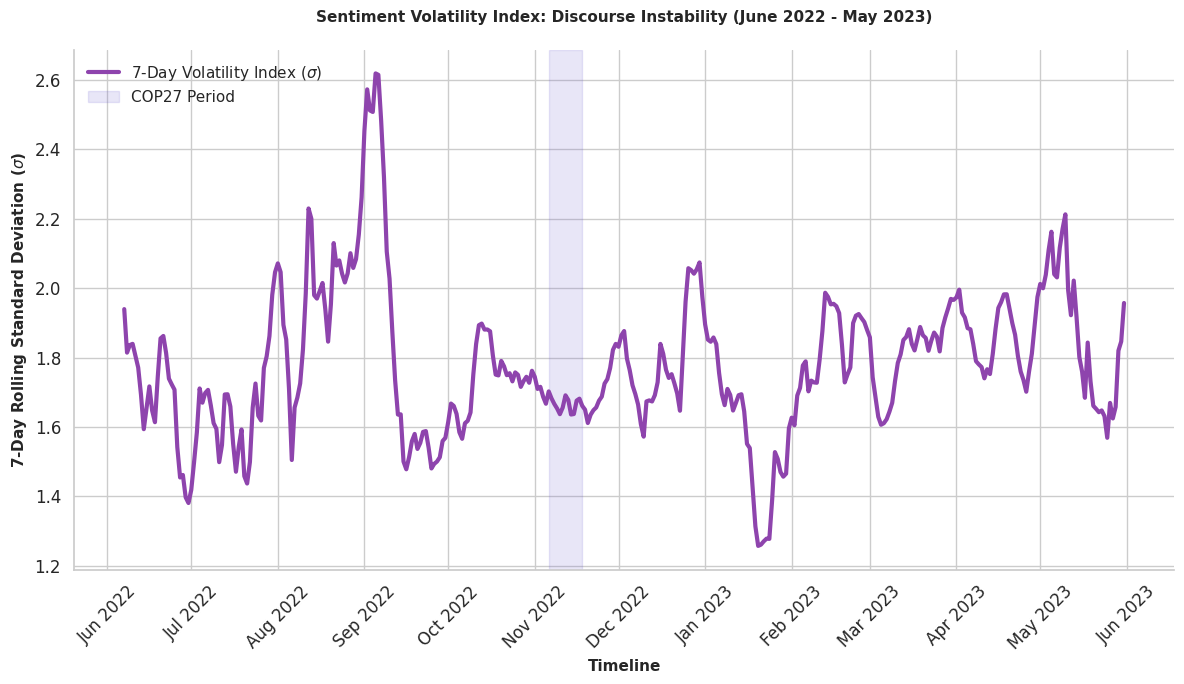

Most Volatile Period peaked around: 2022-09-05


In [ ]:
import matplotlib.dates as mdates

sca_path = '/content/drive/MyDrive/SMA_Das_Biswas_Gul/Climate_Security_Datasets/cs_annotated_June2022toMay2023_FINAL.csv'
df = pd.read_csv(sca_path)
date_col = 'hashtags_net_date'
df[date_col] = pd.to_datetime(df[date_col])
df = df.sort_values(date_col)

# Daily Standard Deviation measures polarization (Volatility)
daily_volatility = df.resample('D', on=date_col)['sentiment_score'].std()

# --- (min_periods=7) ---
rolling_volatility_index = daily_volatility.rolling(window=7, min_periods=7).mean()

# --- Visualization ---
plt.figure(figsize=(12, 7))
sns.set_style("whitegrid")

# Plot Line
plt.plot(rolling_volatility_index.index, rolling_volatility_index,
         color='#8E44AD', linewidth=3, label='7-Day Volatility Index ($\sigma$)')

# Highlight COP27 Summit Period
plt.axvspan(pd.Timestamp('2022-11-06'), pd.Timestamp('2022-11-18'),
            color='slateblue', alpha=0.15, label='COP27 Period')

plt.title('Sentiment Volatility Index: Discourse Instability (June 2022 - May 2023)',
          fontsize=11, fontweight='bold', pad=20, loc='center')
plt.ylabel('7-Day Rolling Standard Deviation ($\sigma$)', fontsize=11, fontweight='bold')
plt.xlabel('Timeline', fontsize=11, fontweight='bold')

# Formatting Ticks
plt.xticks(rotation=45, fontsize=12, fontweight='normal')
plt.yticks(fontsize=12, fontweight='normal')

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

plt.legend(loc='upper left', frameon=False)
sns.despine(top=True, right=True)
plt.tight_layout()
plt.show()

# Print Max Volatility Date
max_vol_date = rolling_volatility_index.idxmax()
print(f"Most Volatile Period peaked around: {max_vol_date.strftime('%Y-%m-%d')}")

### 2.6 The Volume-Sentiment Paradox: Spearman Correlation Analysis

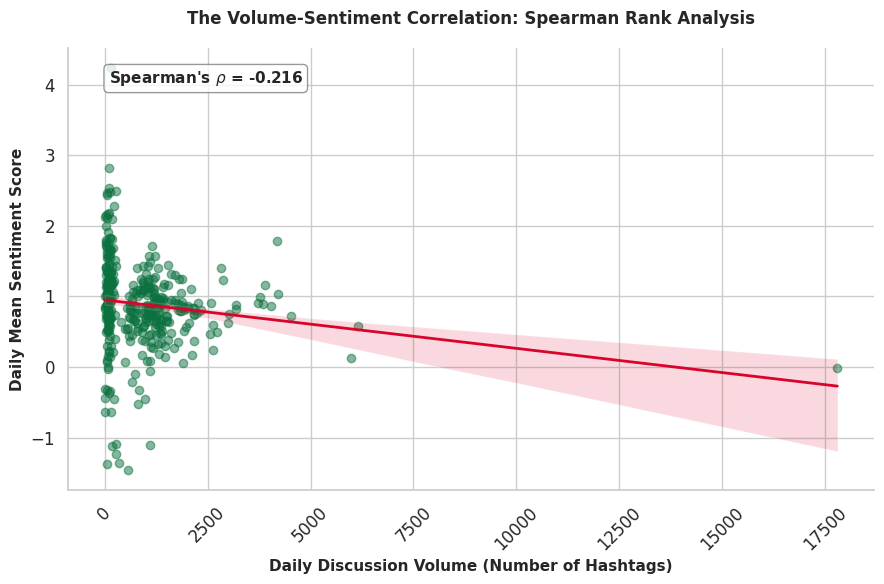


Spearman's Correlation Result (rho): -0.2161


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sca_path = '/content/drive/MyDrive/SMA_Das_Biswas_Gul/Climate_Security_Datasets/cs_annotated_June2022toMay2023_FINAL.csv'
df = pd.read_csv(sca_path)

df = df.dropna(subset=['sentiment_score'])

date_col = 'hashtags_net_date'
df[date_col] = pd.to_datetime(df[date_col])
df = df.sort_values(date_col)

daily_volume = df.resample('D', on=date_col)['sentiment_score'].count().rename('Daily_Volume')
daily_sentiment_mean = df.resample('D', on=date_col)['sentiment_score'].mean().rename('Daily_Sentiment_Mean')
correlation_df = pd.concat([daily_volume, daily_sentiment_mean], axis=1).dropna()

# Spearman's Rank Correlation Coefficient (rho)
correlation_rho = correlation_df['Daily_Volume'].corr(correlation_df['Daily_Sentiment_Mean'], method='spearman')

plt.figure(figsize=(9, 6))
sns.set_style("whitegrid")

# Regression Plot
sns.regplot(
    x='Daily_Volume',
    y='Daily_Sentiment_Mean',
    data=correlation_df,
    scatter_kws={'alpha': 0.5, 'color': '#0b713f'},
    line_kws={'color': '#d90429', 'linewidth': 2},
    robust=True
)

# Spearman's Rho (ρ) Annotation
plt.text(0.05, 0.92, f"Spearman's $\\rho$ = {correlation_rho:.3f}",
         transform=plt.gca().transAxes, fontsize=11, fontweight='bold',
         bbox=dict(boxstyle="round,pad=0.3", facecolor='white', alpha=0.8, edgecolor='gray'))

plt.title('The Volume-Sentiment Correlation: Spearman Rank Analysis',
          fontsize=12, fontweight='bold', pad=17)
plt.ylabel('Daily Mean Sentiment Score', fontsize=11, fontweight='bold')
plt.xlabel('Daily Discussion Volume (Number of Hashtags)', fontsize=11, fontweight='bold')
# Formatting Ticks
plt.xticks(rotation=45, fontsize=12, fontweight='normal')
plt.yticks(fontsize=12, fontweight='normal')
sns.despine()
plt.tight_layout()
plt.show()

print(f"\nSpearman's Correlation Result (rho): {correlation_rho:.4f}")

## 3. Network and Content Synthesis
Integrates structural and content insights by mapping sentiment scores to Louvain communities. Analyzes the emotional tone of top influencers to correlate structural power with sentiment, identifying key paradoxes in the discourse.

### 3.1 Community-Level Sentiment Analysis

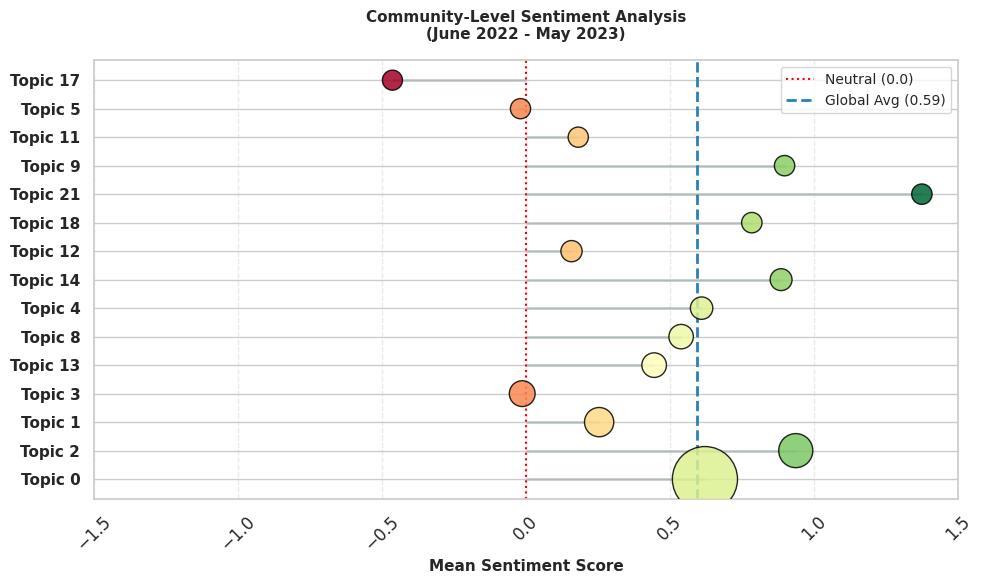


--- Synthesis Summary Table ---


,Topic ID,Sentiment Score (Mean),Hashtag Volume,Tone
0,21,1.373590,5007,Highly Positive
1,2,0.936100,126194,Highly Positive
2,9,0.897208,4745,Highly Positive
3,14,0.885164,15290,Highly Positive
4,18,0.783602,5187,Highly Positive
5,0,0.620978,626942,Highly Positive
6,4,0.609369,18951,Highly Positive
7,8,0.538377,34485,Highly Positive
8,13,0.444823,35698,Positive
9,1,0.253913,76298,Positive


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- Load data ---
sca_path = '/content/drive/MyDrive/SMA_Das_Biswas_Gul/Climate_Security_Datasets/cs_annotated_June2022toMay2023_FINAL.csv'
sna_path = '/content/drive/MyDrive/SMA_Das_Biswas_Gul/Climate_Security_Datasets/sna_communities_June2022toMay2023.csv'

df_sentiment = pd.read_csv(sca_path)
df_topics = pd.read_csv(sna_path)

# --- Preprocess hashtags ---
df_sentiment['tag_list'] = df_sentiment['hashtags'].astype(str)\
    .str.lower().str.replace('#', '', regex=False)\
    .str.split('[,\s;]+')
df_exploded = df_sentiment.explode('tag_list')
df_exploded.rename(columns={'tag_list': 'Id'}, inplace=True)
df_exploded['Id'] = df_exploded['Id'].str.strip()

# --- Merge with community IDs ---
df_synthesis = pd.merge(df_exploded, df_topics[['Id', 'Community_ID']], on='Id', how='inner')

# --- Community sentiment summary ---
comm_sentiment = df_synthesis.groupby('Community_ID')['sentiment_score'].agg(['mean', 'count']).reset_index()
plot_data = comm_sentiment.sort_values(by='count', ascending=False).head(15)
global_avg = df_synthesis['sentiment_score'].mean()

# --- Plot setup ---
fig, ax = plt.subplots(figsize=(10, 6), facecolor='white')

labels = [f"Topic {int(i)}" for i in plot_data['Community_ID']]
y_pos = np.arange(len(labels))
values = plot_data['mean'].values

# --- Bubble sizes (scaled + minimum) ---
sizes = (plot_data['count'].values / plot_data['count'].max()) * 2000 + 200  # big enough + min size

# --- Horizontal lollipop stems ---
ax.hlines(y=y_pos, xmin=0, xmax=values, color='#95a5a6', alpha=0.5, linewidth=2)

# --- Lollipop heads ---
sc = ax.scatter(values, y_pos, s=sizes, c=values, cmap='RdYlGn',
                edgecolor='black', alpha=0.85, zorder=3)

plt.xticks(rotation=45, fontsize=12, fontweight='normal')
# --- Y-axis labels ---
ax.set_yticks(y_pos)
ax.set_yticklabels(labels, fontsize=11, fontweight='bold')

# --- Reference lines ---
ax.axvline(0, color='red', linestyle=':', linewidth=1.5, label='Neutral (0.0)')
ax.axvline(global_avg, color='#2980b9', linestyle='--', linewidth=2,
           label=f'Global Avg ({global_avg:.2f})')

# --- Cosmetics ---
ax.set_xlabel('Mean Sentiment Score', fontsize=11, fontweight='bold')
ax.set_title('Community-Level Sentiment Analysis\n(June 2022 - May 2023)',
             fontsize=11, fontweight='bold', pad=15)

ax.grid(axis='x', linestyle='--', alpha=0.4)
ax.set_xlim(-1.5, 1.5)

ax.legend(loc='upper right', frameon=True, fontsize=10)

plt.tight_layout()
plt.show()

# --- SUMMARY TABLE ---
summary_table = plot_data.copy()
summary_table['Tone'] = summary_table['mean'].apply(
    lambda x: 'Highly Positive' if x > 0.5 else ('Positive' if x > 0 else 'Moderate/Negative')
)
summary_table = summary_table.rename(columns={
    'Community_ID': 'Topic ID',
    'mean': 'Sentiment Score (Mean)',
    'count': 'Hashtag Volume'
})

print("\n--- Synthesis Summary Table ---")
display(summary_table.sort_values(by='Sentiment Score (Mean)', ascending=False).reset_index(drop=True))


### 3.2 Influencer-Level Sentiment Analysis

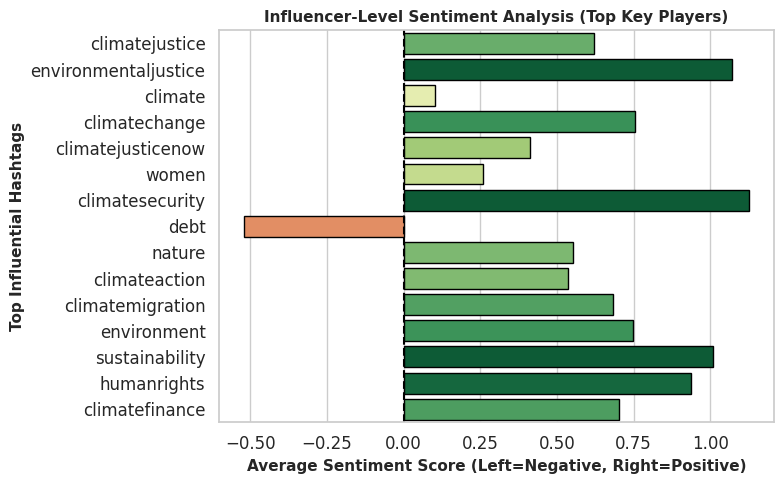


--- Sentiment of Top Influencers (with Frequency & Combined Score) ---


,Hashtag,Betweenness_Centrality,Hashtag_Frequency,sentiment_score,Combined_Score
0,climatejustice,0.233679,223282,0.619522,0.769360
1,environmentaljustice,0.162954,47055,1.070213,0.632116
2,climate,0.041394,20253,0.100888,0.341722
3,climatechange,0.015539,20284,0.754862,0.306839
4,climatesecurity,0.008857,7601,1.124742,0.304099
5,climatejusticenow,0.011275,21166,0.411497,0.286984
6,sustainability,0.002070,2538,1.007622,0.285917
7,humanrights,0.001962,6966,0.938061,0.283512
8,women,0.010661,2779,0.258683,0.280894
9,climatemigration,0.004200,4575,0.682449,0.280314


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


cent_path = '/content/drive/MyDrive/SMA_Das_Biswas_Gul/Climate_Security_Datasets/sna_centrality_June2022toMay2023.csv'
sca_path = '/content/drive/MyDrive/SMA_Das_Biswas_Gul/Climate_Security_Datasets/cs_annotated_June2022toMay2023_FINAL.csv'

df_cent = pd.read_csv(cent_path)
df_sca = pd.read_csv(sca_path)

# --- Preprocess Hashtags ---
df_sca['tag_list'] = df_sca['hashtags'].astype(str).str.lower().str.replace('#', '', regex=False).str.split('[,\s;]+')
df_exploded = df_sca.explode('tag_list')
df_exploded.rename(columns={'tag_list': 'Hashtag'}, inplace=True)
df_exploded['Hashtag'] = df_exploded['Hashtag'].str.strip()

# --- Hashtag Stats: Mean Sentiment + Frequency ---
hashtag_stats = df_exploded.groupby('Hashtag')['sentiment_score'].agg(['mean', 'count']).reset_index()
hashtag_stats.rename(columns={'mean': 'sentiment_score', 'count': 'Hashtag_Frequency'}, inplace=True)

# --- Merge with Centrality Data ---
df_influencers = pd.merge(df_cent, hashtag_stats, on='Hashtag', how='inner')

# --- Normalize for Combined Score ---
df_influencers['norm_cent'] = (df_influencers['Betweenness_Centrality'] - df_influencers['Betweenness_Centrality'].min()) / \
                              (df_influencers['Betweenness_Centrality'].max() - df_influencers['Betweenness_Centrality'].min())
df_influencers['norm_sent'] = (df_influencers['sentiment_score'] - df_influencers['sentiment_score'].min()) / \
                              (df_influencers['sentiment_score'].max() - df_influencers['sentiment_score'].min())
df_influencers['Combined_Score'] = (df_influencers['norm_cent'] + df_influencers['norm_sent']) / 2

# --- Select Top 15 Influencers by Betweenness Centrality ---
top_influencers = df_influencers.sort_values(by='Betweenness_Centrality', ascending=False).head(15)

# --- Plot ---
plt.figure(figsize=(8, 5))
sns.set_style("whitegrid")

norm = plt.Normalize(-1, 1)
colors = plt.cm.RdYlGn(norm(top_influencers['sentiment_score']))

sns.barplot(
    x='sentiment_score',
    y='Hashtag',
    data=top_influencers,
    palette=colors,
    edgecolor='black'
)

plt.axvline(0, color='black', linestyle='--', linewidth=1.5, label='Neutral Line')
plt.title('Influencer-Level Sentiment Analysis (Top Key Players)', fontsize=11, fontweight='bold')
plt.xlabel('Average Sentiment Score (Left=Negative, Right=Positive)', fontsize=11, fontweight='bold')
plt.ylabel('Top Influential Hashtags', fontsize=11, fontweight='bold')
plt.xticks(fontsize=12, fontweight='normal')
plt.yticks(fontsize=12, fontweight='normal')
plt.tight_layout()
plt.show()

# --- Display Table with Frequency & Combined Score ---
summary_table = top_influencers[['Hashtag', 'Betweenness_Centrality', 'Hashtag_Frequency', 'sentiment_score', 'Combined_Score']].copy()
summary_table = summary_table.sort_values(by='Combined_Score', ascending=False).reset_index(drop=True)

print("\n--- Sentiment of Top Influencers (with Frequency & Combined Score) ---")
display(summary_table)
